In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from tqdm import tqdm
import os
from pathlib import Path


In [2]:
coordinates_path = Path("/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021_triangulated_points_20250802-065459.h5")

In [3]:
# load the coordinates:
data = xr.open_dataset(coordinates_path)

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [18]:
# get max, min value for each dimension:
for dim in range(data.position.shape[1]):
    print(f"Dimension {dim}:")
    print(f"  Max value: {data.position[:, dim, ...].max().values}")
    print(f"  Min value: {data.position[:, dim, ...].min().values}")
    print(f"  Mean value: {data.position[:, dim, ...].mean().values}")
    print(f"  Median value: {np.median(data.position[:, dim, ...].values)}")
    print(f"  Standard deviation: {data.position[:, dim, ...].std().values}")

Dimension 0:
  Max value: 4161.337505112246
  Min value: -33203.9494573142
  Mean value: 11.884648066956201
  Median value: 82.2357387171931
  Standard deviation: 112.0987189609319
Dimension 1:
  Max value: 40286.782731647225
  Min value: -5924.840005945679
  Mean value: -52.35860607911988
  Median value: -113.62901059591513
  Standard deviation: 121.87383801397763
Dimension 2:
  Max value: 28204.471663744553
  Min value: 631.1914236775026
  Mean value: 990.9745054059777
  Median value: 986.384091922628
  Standard deviation: 31.483779832635516


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [79]:
sample_data = data.position.isel(time=slice(0, 100)).values

In [47]:
centroids = sample_data.mean(axis=2).squeeze()
centroids.shape


(100, 3)

In [ ]:
disp = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])

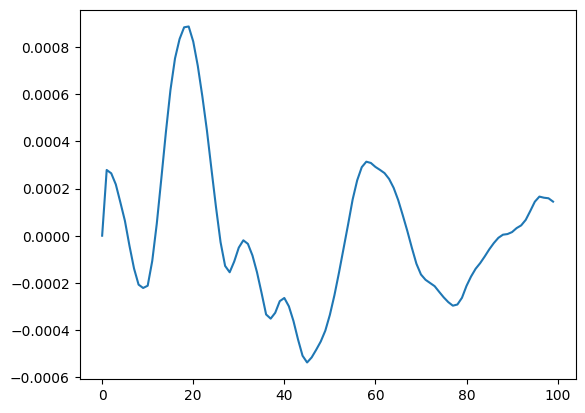

In [59]:
plt.figure()
plt.plot(disp[:, 2])
plt.show()

In [232]:
# function to ge the velocity 
from typing import Any


def get_velocity(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Calculate velocity from position data
    
    Args:
        session (xr.Dataset): The input dataset containing position data
        time_slice (slice): The time slice to calculate velocity over
        
    Returns:
        np.ndarray: The velocity data
    """
    if time_slice:
        coordinates = session.position.isel(time=slice(0,time_slice)).values
    centroids = coordinates.mean(axis=2).squeeze()
    displacement = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])
    velocity = displacement 
    velocity = np.linalg.norm(velocity, axis=1)
    return velocity

def get_accelleration(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Calculate accelleration from position data
    
    Args:
        session (xr.Dataset): The input dataset containing position data
        time_slice (slice): The time slice to calculate accelleration over
        
    Returns:
        np.ndarray: The accelleration data
    """
    if time_slice:
        coordinates = session.position.isel(time=slice(0,time_slice)).values
    centroids = coordinates.mean(axis=2).squeeze()
    displacement = np.vstack([np.zeros((1, 3)), np.diff(centroids, axis=0)])
    velocity = displacement 
    accelleration = np.vstack([np.zeros((1, 3)), np.diff(velocity, axis=0)]) 
    accelleration = np.linalg.norm(accelleration, axis=1)
    return accelleration

def get_head_rear(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the verrtifical movement of the head as an heuristic of rear

    Args:
        session(xr.Dataset): input xrarray 
        time_slice: int max frame
    Returns:
        np.ndarray
    """
    rear = data["position"].sel(keypoints=["nose", "ear_lf", "ear_rt"], space="z").isel(time=slice(0, time_slice)).values.squeeze()
    return rear
def get_theta(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the theta angle of the head in the 2D xy space
    
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
    Returns:
        The direction fo the head in the 2D xy space [-pi, pi]
    """
    keypoint_1, keypoint_2 = keypoints
    diff = data["position"].sel(keypoints=keypoint_1).values - data["position"].sel(keypoints=keypoint_2).values
    diff = diff[:time_slice]
    diff_norm = np.linalg.norm(diff, axis=1)
    v_x = diff[:, 0] / diff_norm
    v_y = diff[:, 1] / diff_norm
    theta_head = np.arctan2(v_y, v_x)
    return theta_head
    
def get_turning_rate(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the turning rate of the head
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
        keypoints: tuple of keypoints
    Returns:
        np.ndarray: turning rate
    """
    theta_head = get_theta(session, time_slice, keypoints)
    dtheta = np.vstack([np.zeros((1,)), np.diff(theta_head, axis=0)])
    #wrapped to [-pi, pi]
    dtheta = np.mod(dtheta + np.pi, 2 * np.pi) - np.pi
    dtheta = dtheta 
    return dtheta
def yaw_offset(session:xr.Dataset, time_slice:int)->np.ndarray:
    """
    Computes the yaw offset of the head
    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
    Returns:
        np.ndarray: 0 (body and head are aligned), >0 (head is left of body), <0 (head is right of body)
    """
    theta_body = get_theta(session, time_slice, ("back_mid", "tailbase"))
    theta_head = get_theta(session, time_slice, ("nose", "tailbase"))
    delta_theta = theta_head - theta_body
    #wrap to [-pi, pi]
    delta_theta = np.mod(delta_theta + np.pi, 2 * np.pi) - np.pi
    return delta_theta

def pitch_angle(session:xr.Dataset, time_slice:int, keypoints:tuple)->np.ndarray:
    """
    Computes the pitch angle of the head

    Args:
        session(xr.Dataset): input xr.Dataset
        time_slice: int max frame
        keypoints: tuple of keypoints
    Returns:
        np.ndarray: pitch angle
        pitch = 0 when head and body are aligned, pitch > 0 when head is up, pitch < 0 when head is down
    """
    keypoint_1, keypoint_2 = keypoints
    if time_slice:
        v_nose = session.position.sel(keypoints=keypoint_1).values[:time_slice]
        v_tailbase = session.position.sel(keypoints=keypoint_2).values[:time_slice]
    else:
        v_nose = session.position.sel(keypoints=keypoint_1).values
        v_tailbase = session.position.sel(keypoints=keypoint_2).values
    v_body = v_nose - v_tailbase
    # compute horizontal (ground-plane) lenght 
    L_xy = np.linalg.norm(v_body[:, :2], axis=1)
    #compute pitch angle
    pitch_angle = np.arctan2(v_body[:, 2], L_xy)
    return pitch_angle

In [238]:
velocity = get_velocity(data, time_slice=1000)
acc = get_accelleration(data, time_slice=1000)
rear = get_head_rear(data, time_slice=1000)
theta_head = get_theta(data, time_slice=100, keypoints=("nose", "tailbase"))
turning_rate = get_turning_rate(data, time_slice=1000, keypoints=("nose", "tailbase"))
yaw_offset = yaw_offset(data, time_slice=1000)
pitch_angle = pitch_angle(data, time_slice=1000, keypoints=("nose", "tailbase"))

TypeError: 'numpy.ndarray' object is not callable

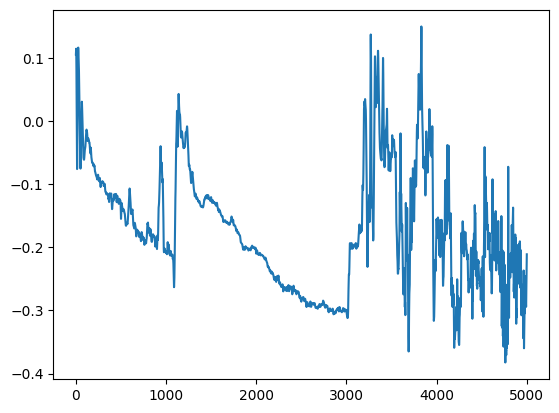

In [234]:
plt.figure()
plt.plot(pitch_angle)
plt.show()